In [1]:
import os
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
# Define paths
base_dir = 'Data'

# Define image data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,   # normalize pixel values between 0 and 1
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'  # Use 'training' subset
)

validation_generator = test_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'  # Use 'validation' subset
)


Found 1282 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [3]:
# Define a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')  # Adjust the output layer based on number of classes
])


In [4]:
# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=30
)

# Save the model
model.save('poverty_detect_satelight.h5')


Epoch 1/30
40/40 [==============================] - 61s 1s/step - loss: 0.6259 - accuracy: 0.8136
Epoch 2/30
40/40 [==============================] - 47s 1s/step - loss: 0.1914 - accuracy: 0.9304
Epoch 3/30
40/40 [==============================] - 47s 1s/step - loss: 0.1559 - accuracy: 0.9424
Epoch 4/30
40/40 [==============================] - 47s 1s/step - loss: 0.1646 - accuracy: 0.9392
Epoch 5/30
40/40 [==============================] - 47s 1s/step - loss: 0.1334 - accuracy: 0.9480
Epoch 6/30
40/40 [==============================] - 46s 1s/step - loss: 0.1344 - accuracy: 0.9544
Epoch 7/30
40/40 [==============================] - 45s 1s/step - loss: 0.1364 - accuracy: 0.9448
Epoch 8/30
40/40 [==============================] - 44s 1s/step - loss: 0.1173 - accuracy: 0.9488
Epoch 9/30
40/40 [==============================] - 44s 1s/step - loss: 0.1367 - accuracy: 0.9416
Epoch 10/30
40/40 [==============================] - 44s 1s/step - loss: 0.1246 - accuracy: 0.9520
Epoch 11/30
40/40 [

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


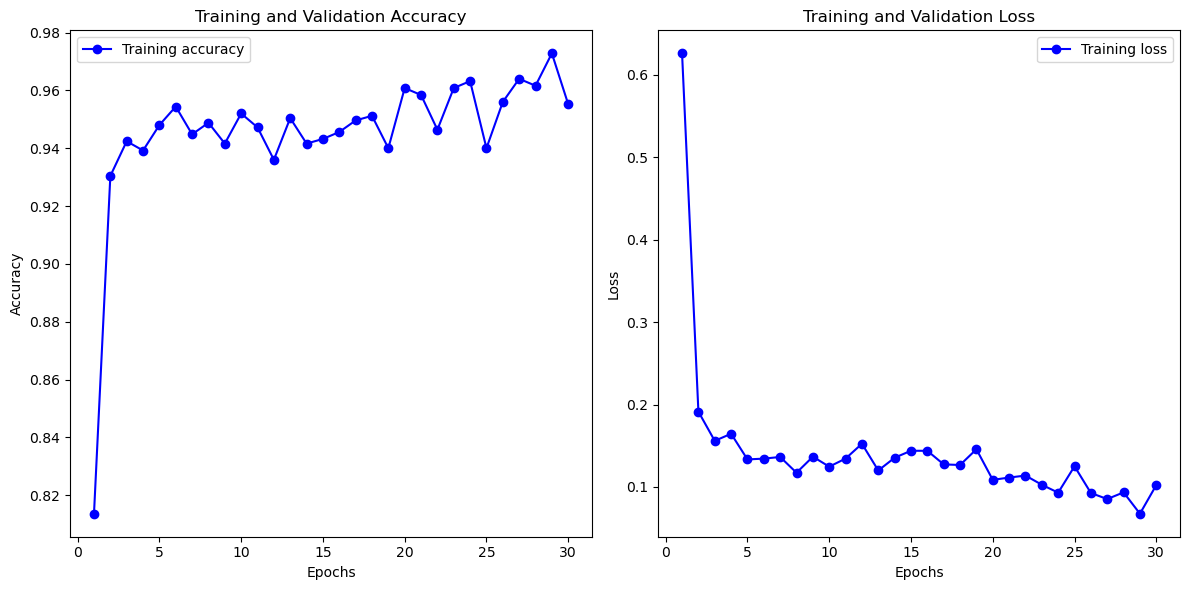

In [6]:
import matplotlib.pyplot as plt

# Plotting the training history
def plot_training_history(history):
    # Get the training metrics
    acc = history.history['accuracy']
    loss = history.history['loss']
    
    # Check if validation metrics exist
    if 'val_accuracy' in history.history:
        val_acc = history.history['val_accuracy']
        val_loss = history.history['val_loss']
        has_validation = True
    else:
        has_validation = False
    
    # Get the number of epochs
    epochs = range(1, len(acc) + 1)
    
    # Plot training and validation accuracy (if available)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training accuracy')
    if has_validation:
        plt.plot(epochs, val_acc, 'ro-', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot training and validation loss (if available)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    if has_validation:
        plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Show the plots
    plt.tight_layout()
    plt.show()

# Call the function to plot the training history
plot_training_history(history)
